In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Добавим необходимые библиотеки для первичной обработки данных  
pandas - чтение и обработка данных  
numpy - чтение и обработка данных   
matplotlip.pyplot - построение и анализ графиков  
seaborn - построение и анализ графиков

In [3]:
df = pd.read_csv('../data/raw.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Видим, что нет пропусков - значит данные хорошие.

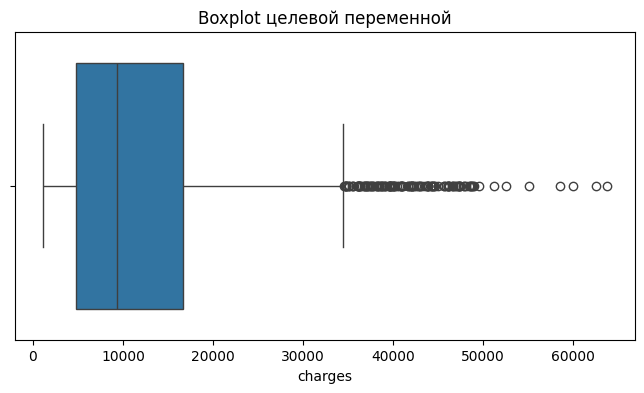

In [5]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["charges"])
plt.title("Boxplot целевой переменной")
plt.xlabel("charges")
plt.show()

По графику boxplot видно, что у целевой переменной присутствуют выбросы.  
Но нельзя пока говорить, что это аномалии, нужно проверить данные.

In [6]:
df[df["charges"] > 35000]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


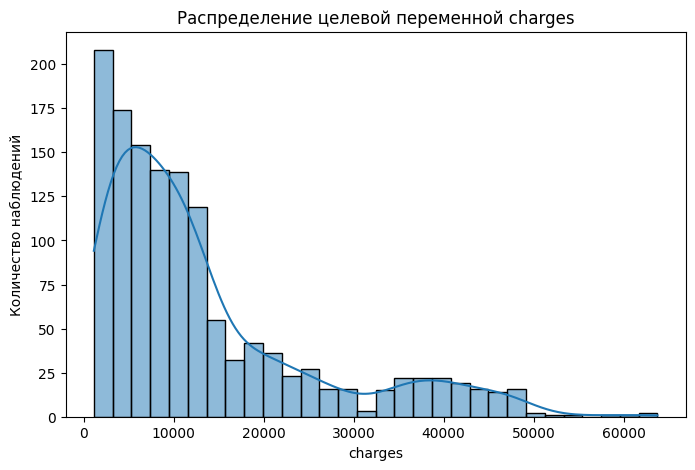

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df["charges"], kde=True, bins=30)
plt.title("Распределение целевой переменной charges")
plt.xlabel("charges")
plt.ylabel("Количество наблюдений")
plt.show()

Видим, что распределение целевой имеет правиостороннюю ассиметрию. Основная часть значений меньше 20000.

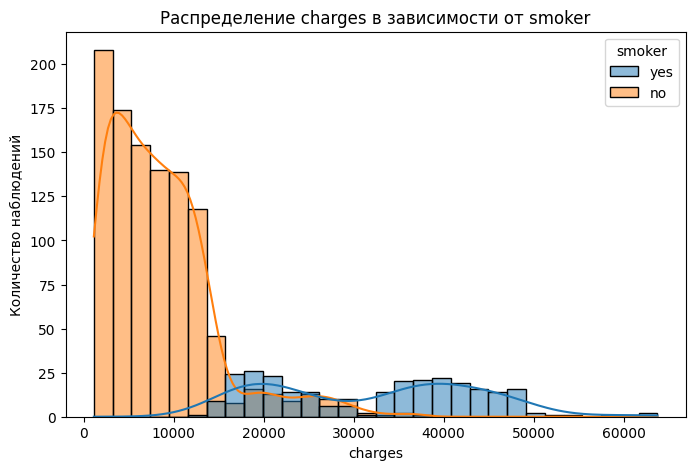

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="charges", hue="smoker", kde=True, bins=30)
plt.title("Распределение charges в зависимости от smoker")
plt.xlabel("charges")
plt.ylabel("Количество наблюдений")
plt.show()

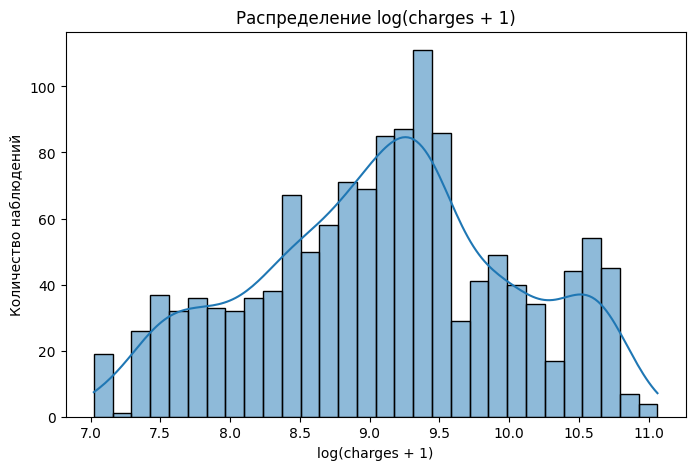

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(df["charges"]), kde=True, bins=30)
plt.title("Распределение log(charges + 1)")
plt.xlabel("log(charges + 1)")
plt.ylabel("Количество наблюдений")
plt.show()

In [10]:
df_one_hot = pd.get_dummies(df, drop_first=True, dtype=int)
df_one_hot

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,1,0,1,0,0
1334,18,31.920,0,2205.98080,0,0,0,0,0
1335,18,36.850,0,1629.83350,0,0,0,1,0
1336,21,25.800,0,2007.94500,0,0,0,0,1


В этом методе количество features может измениться во много раз, но не в нашем случае.

In [11]:
from sklearn.preprocessing import OrdinalEncoder
categorical_cols = ['sex', 'smoker', 'region']
encoder = OrdinalEncoder()
df_ordinal_encoded = df.copy()
df_ordinal_encoded[categorical_cols] = encoder.fit_transform(df_ordinal_encoded[categorical_cols])
df_ordinal_encoded

,age,sex,bmi,children,smoker,region,charges
0,19,0.0,27.900,0,1.0,3.0,16884.92400
1,18,1.0,33.770,1,0.0,2.0,1725.55230
2,28,1.0,33.000,3,0.0,2.0,4449.46200
3,33,1.0,22.705,0,0.0,1.0,21984.47061
4,32,1.0,28.880,0,0.0,1.0,3866.85520
...,...,...,...,...,...,...,...
1333,50,1.0,30.970,3,0.0,1.0,10600.54830
1334,18,0.0,31.920,0,0.0,0.0,2205.98080
1335,18,0.0,36.850,0,0.0,2.0,1629.83350
1336,21,0.0,25.800,0,0.0,3.0,2007.94500


Здесь же мы не изменяем количество features.

In [12]:
from pathlib import Path
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)
df_ordinal_encoded.to_csv(processed_dir / 'raw_ordinal_encoded.csv', index=False)
df_one_hot.to_csv(processed_dir / 'raw_one_hot.csv', index=False)

Загрузили данные в папку processed два новых преобразованных датасета для дальнейшей работы.

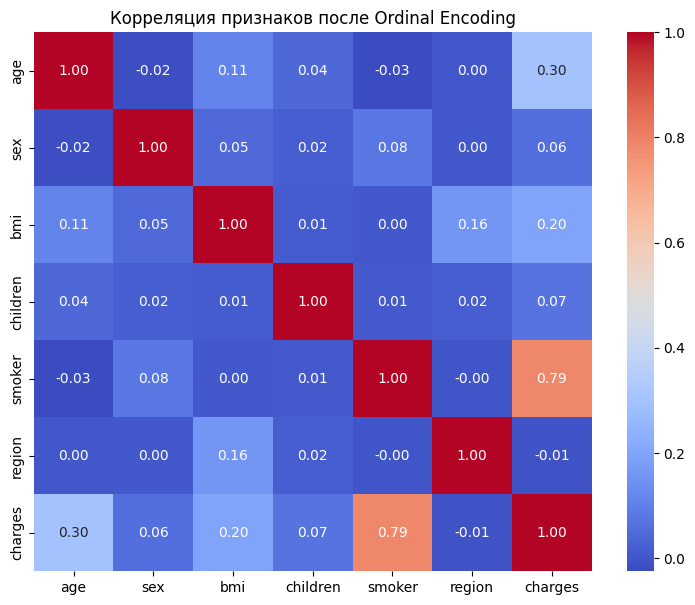

In [13]:
df_corr = df_ordinal_encoded.copy()
corr = df_corr.corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция признаков после Ordinal Encoding')
plt.show()

по матрице корреляции признаков мы видим, что есть одна сильная корреляция между целевой переменной и курением. Но также нельзя сбрасывать cо счетов region-bmi, target-bmi, age-target.

## Стратифицированное разделение данных

Для задачи регрессии целевая переменная `charges` непрерывная, поэтому напрямую использовать `stratify=y` нельзя. Сначала разобьем `charges` на интервалы, а затем совместим эти интервалы с признаком `smoker`, потому что курение сильнее всего связано со стоимостью страховки.

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['charges'])
y = df['charges']

charge_bins = pd.qcut(y, q=5, labels=False, duplicates='drop')
strata = df['smoker'].astype(str) + '_' + charge_bins.astype(str)

X_train_val, X_test, y_train_val, y_test, strata_train_val, strata_test = train_test_split(
    X,
    y,
    strata,
    test_size=0.2,
    random_state=42,
    stratify=strata
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=strata_train_val
)

print('X_train shape:', X_train.shape)
print('X_val shape:', X_val.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_val shape:', y_val.shape)
print('y_test shape:', y_test.shape)

X_train shape: (802, 6)
X_val shape: (268, 6)
X_test shape: (268, 6)
y_train shape: (802,)
y_val shape: (268,)
y_test shape: (268,)


In [15]:
print('Доля smoker в train:')
print(X_train['smoker'].value_counts(normalize=True))

print('\nДоля smoker в test:')
print(X_test['smoker'].value_counts(normalize=True))

print('\nОписание charges в train:')
print(y_train.describe())

print('\nОписание charges в test:')
print(y_test.describe())

Доля smoker в train:
smoker
no     0.794264
yes    0.205736
Name: proportion, dtype: float64

Доля smoker в test:
smoker
no     0.794776
yes    0.205224
Name: proportion, dtype: float64

Описание charges в train:
count      802.000000
mean     13383.783240
std      12288.628387
min       1121.873900
25%       4746.521225
50%       9565.009950
75%      16728.852465
max      62592.873090
Name: charges, dtype: float64

Описание charges в test:
count      268.000000
mean     12739.909914
std      11268.519590
min       1149.395900
25%       4981.654712
50%       9211.815425
75%      14782.750163
max      58571.074480
Name: charges, dtype: float64


## Ordinal Encoding после разделения

Кодировщик обучаем только на `X_train`, а к `X_test` применяем уже обученный encoder. Так тестовая выборка не участвует в подготовке признаков.

In [16]:
from sklearn.preprocessing import OrdinalEncoder
categorical_cols = ['sex', 'smoker', 'region']

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_encoded = X_train.copy()
X_val_encoded = X_val.copy()
X_test_encoded = X_test.copy()

X_train_encoded[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])
X_val_encoded[categorical_cols] = encoder.transform(X_val[categorical_cols])
X_test_encoded[categorical_cols] = encoder.transform(X_test[categorical_cols])

X_train_encoded.head()

,age,sex,bmi,children,smoker,region
387,50,1.0,25.365,2,0.0,1.0
1230,52,1.0,34.485,3,1.0,1.0
349,19,1.0,27.835,0,0.0,1.0
809,25,1.0,25.840,1,0.0,0.0
1207,36,1.0,33.400,2,1.0,3.0


In [17]:
for col, categories in zip(categorical_cols, encoder.categories_):
    print(col, dict(zip(categories, range(len(categories)))))

sex {'female': 0, 'male': 1}
smoker {'no': 0, 'yes': 1}
region {'northeast': 0, 'northwest': 1, 'southeast': 2, 'southwest': 3}


## Сохранение train/test выборок

Сохраним уже разделенные и закодированные данные, чтобы дальше использовать их в ноутбуках с моделями.

In [18]:
from pathlib import Path

train_ordinal_encoded = X_train_encoded.copy()
train_ordinal_encoded['charges'] = y_train

validation_ordinal_encoded = X_val_encoded.copy()
validation_ordinal_encoded['charges'] = y_val

test_ordinal_encoded = X_test_encoded.copy()
test_ordinal_encoded['charges'] = y_test

processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

train_ordinal_encoded.to_csv(processed_dir / 'train_ordinal_encoded.csv', index=False)
validation_ordinal_encoded.to_csv(processed_dir / 'validation_ordinal_encoded.csv', index=False)
test_ordinal_encoded.to_csv(processed_dir / 'test_ordinal_encoded.csv', index=False)

train_ordinal_encoded.head()

,age,sex,bmi,children,smoker,region,charges
387,50,1.0,25.365,2,0.0,1.0,30284.64294
1230,52,1.0,34.485,3,1.0,1.0,60021.39897
349,19,1.0,27.835,0,0.0,1.0,1635.73365
809,25,1.0,25.840,1,0.0,0.0,3309.79260
1207,36,1.0,33.400,2,1.0,3.0,38415.47400
